In [3]:
import nltk
nltk.download('treebank')
from nltk.corpus import treebank

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [6]:
sentences = treebank.tagged_sents()
first_sentence = sentences[0]

# separate the words and the corresponding POS tags
words = []
pos_order = []
for word, pos in first_sentence:
    words.append(word)
    pos_order.append(pos)

# printing sentence and order of POS tags --> visualization of how the data looks like
print("Sentence:", " ".join(words))
print("POS Order:", " ".join(pos_order))

Sentence: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
POS Order: NNP NNP , CD NNS JJ , MD VB DT NN IN DT JJ NN NNP CD .


In [7]:
# Create sentence-level data
sentences_text = [" ".join([word for word, _ in sentence]) for sentence in sentences]
sentence_lengths = [len(sentence) for sentence in sentences]

print(len(sentences_text[0].split(' ')))

# print(len(sentences_text)) #3914 sentences

# printing to visualize the structure
print("Sample sentence length data:")
for i in range(3):  # Show first 3 examples
    print(f"Sentence {i+1}: {sentences_text[i]}")
    print(f"Length: {sentence_lengths[i]}")
    print()

18
Sample sentence length data:
Sentence 1: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
Length: 18

Sentence 2: Mr. Vinken is chairman of Elsevier N.V. , the Dutch publishing group .
Length: 13

Sentence 3: Rudolph Agnew , 55 years old and former chairman of Consolidated Gold Fields PLC , was named *-1 a nonexecutive director of this British industrial conglomerate .
Length: 27



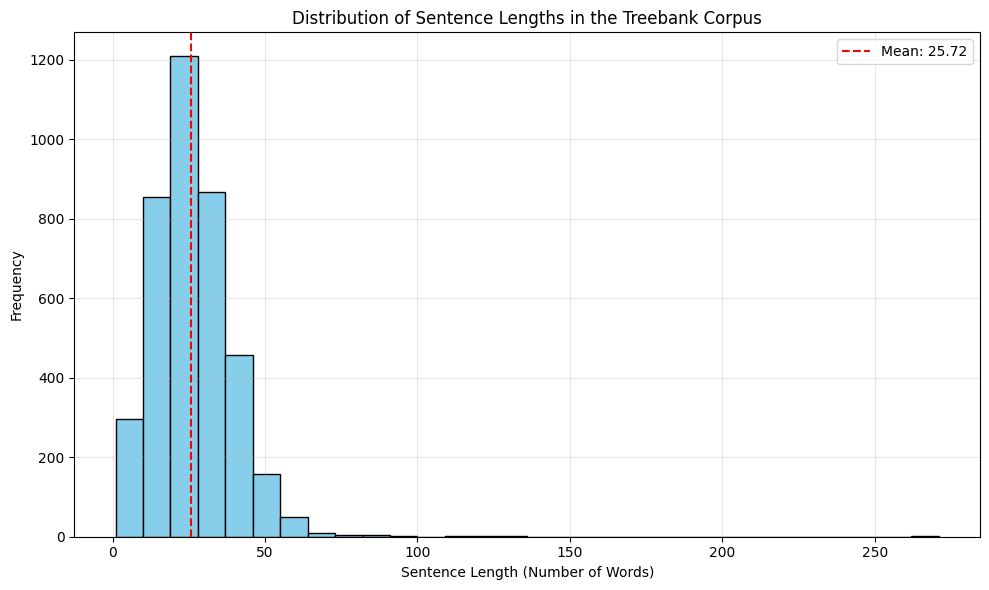

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(sentence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths in the Treebank Corpus')
plt.xlabel('Sentence Length (Number of Words)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.axvline(x=sum(sentence_lengths)/len(sentence_lengths), color='red', linestyle='--', label=f'Mean: {sum(sentence_lengths)/len(sentence_lengths):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Sentence Length Statistics:
Number of sentences: 3914
Mean length: 25.72 words
Median length: 25.00 words
Mode length: 22 words
Standard deviation: 12.87 words
Minimum length: 1 words
Maximum length: 271 words
25th percentile: 17.00 words
75th percentile: 33.00 words


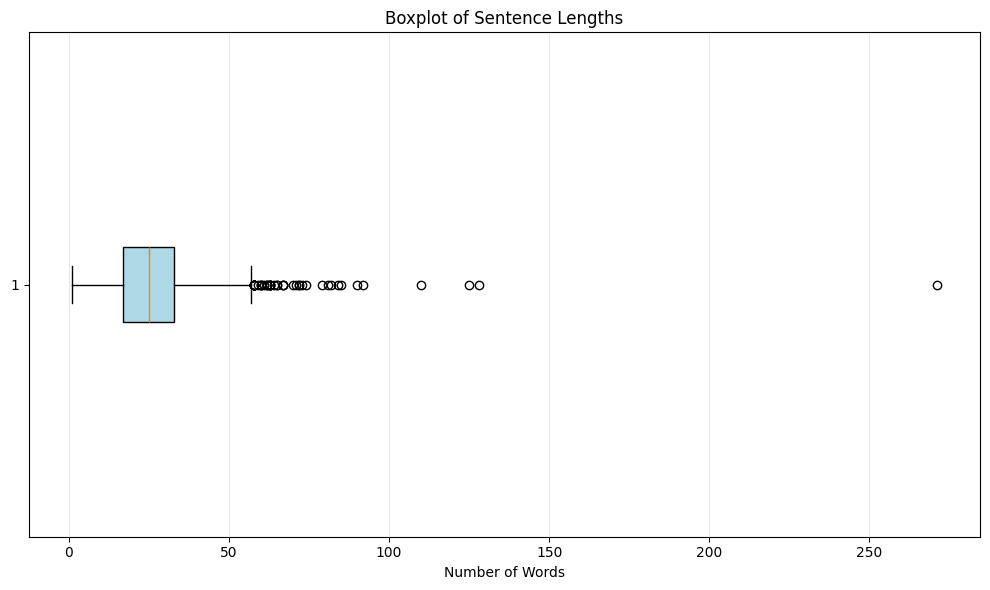

In [13]:
import numpy as np
from scipy import stats

# Calculate basic statistics
mean_length = np.mean(sentence_lengths)
median_length = np.median(sentence_lengths)
std_length = np.std(sentence_lengths)
min_length = min(sentence_lengths)
max_length = max(sentence_lengths)
mode_length = stats.mode(sentence_lengths, keepdims=False)[0]

# Print the statistics
print(f"Sentence Length Statistics:")
print(f"Number of sentences: {len(sentence_lengths)}")
print(f"Mean length: {mean_length:.2f} words")
print(f"Median length: {median_length:.2f} words")
print(f"Mode length: {mode_length} words")
print(f"Standard deviation: {std_length:.2f} words")
print(f"Minimum length: {min_length} words")
print(f"Maximum length: {max_length} words")
print(f"25th percentile: {np.percentile(sentence_lengths, 25):.2f} words")
print(f"75th percentile: {np.percentile(sentence_lengths, 75):.2f} words")

# Create a boxplot to visualize the distribution
plt.figure(figsize=(10, 6))
plt.boxplot(sentence_lengths, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot of Sentence Lengths')
plt.xlabel('Number of Words')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()